# Problem 1 — Word embeddings from IIT Jodhpur text

This notebook trains **Word2Vec** on your **cleaned corpus** in `PA1_Task1_output/` and analyses semantics + plots.

**Note from class:** For Word2Vec you should implement **from scratch** (we use **PyTorch** for the math: embeddings, sigmoid, negative sampling, optimisation) and **compare** to a **library** implementation (**Gensim**). PyTorch is fine for activations and gradient descent — you do not need to write SGD in NumPy by hand.

| Task | What we do here |
|------|-----------------|
| **TASK-1** | Load the **pre-built corpus** from `PA1_Task1_output/`, report stats, word cloud |
| **TASK-2** | Gensim **CBOW** + **Skip-gram** (grid over dim / window / negative); PyTorch **Skip-gram + neg sampling** from scratch; compare |
| **TASK-3** | Cosine neighbours + analogies |
| **TASK-4** | PCA / t-SNE plots for CBOW vs Skip-gram |


## TASK-1 — Dataset preparation

We use the **clean corpus you already built** for the assignment:

- `PA1_Task1_output/clean_corpus.txt` — one sentence per line (input to Word2Vec).
- `PA1_Task1_output/corpus_statistics.json` — optional: document counts / tokens / vocab from your preprocessing pipeline.

Below we **reload** the text to compute the word cloud and print statistics in this notebook (so figures match what you submit). If JSON stats differ slightly from a fresh token count, that is normal (different tokenisation rules).


In [45]:
# pip install wordcloud matplotlib pandas numpy gensim torch scikit-learn


In [46]:
# Corpus paths (pre-built in PA1_Task1_output)
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wordcloud import STOPWORDS

BASE = Path.cwd()
OUT_DIR = BASE / "PA1_Task1_output"
CLEAN_PATH = OUT_DIR / "clean_corpus.txt"
STATS_JSON = OUT_DIR / "corpus_statistics.json"

if not CLEAN_PATH.is_file():
    raise FileNotFoundError(f"Missing {CLEAN_PATH} — run your Task-1 pipeline first.")


def stopwords_for_report():
    # English stopwords + site-specific tokens (same idea as PA1_Task1.py)
    s = set(STOPWORDS)
    s.update(["iit", "jodhpur", "iitj", "www", "http", "https", "ac", "in"])
    return s


def top_content_words(freq: Counter, stop: set[str], n: int = 50):
    # Most common words after dropping stopwords and very short words
    ranked = []
    for word, count in freq.items():
        if word not in stop and len(word) > 2:
            ranked.append((word, count))
    ranked.sort(key=lambda x: -x[1])
    return ranked[:n]


STOP_REPORT = stopwords_for_report()

# Load optional statistics from your earlier run
if STATS_JSON.is_file():
    with STATS_JSON.open(encoding="utf-8") as f:
        stats_saved = json.load(f)
    print("--- From corpus_statistics.json (Task-1 run) ---")
    print("total_documents:", stats_saved.get("total_documents"))
    print("total_chunks / lines:", stats_saved.get("total_chunks"))
    print("total_tokens:", stats_saved.get("total_tokens"))
    print("vocabulary_size:", stats_saved.get("vocabulary_size"))
else:
    stats_saved = None
    print("(No corpus_statistics.json found — only printing stats from this notebook.)")

# Read corpus lines for this notebook
cleaned_lines = []
with CLEAN_PATH.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            cleaned_lines.append(line)

all_tokens = []
for line in cleaned_lines:
    all_tokens.extend(line.split())

n_lines = len(cleaned_lines)
n_tokens = len(all_tokens)
vocab = set(all_tokens)
vocab_size = len(vocab)

# Content words only (for word cloud + top-word lists; same filters as PA1_Task1.py)
content_tokens_list = []
for w in all_tokens:
    if w not in STOP_REPORT and len(w) > 2:
        content_tokens_list.append(w)
freq_content = Counter(content_tokens_list)
content_vocab = set(content_tokens_list)

print()
print("--- Recomputed in this notebook (from clean_corpus.txt) ---")
print("Cleaned lines (sentences):", n_lines)
print("Total tokens (split on whitespace):", n_tokens)
print("Vocabulary size (unique tokens, all words):", vocab_size)
print()
print("--- Content words only (no English stopwords; len > 2; IIT/site junk removed) ---")
print("Content tokens:", len(content_tokens_list))
print("Content vocabulary size:", len(content_vocab))
print("Corpus file used:", CLEAN_PATH)
print()
print("(Word2Vec models below still train on full sentences — we only filter for the word cloud and tables.)")


--- From corpus_statistics.json (Task-1 run) ---
total_documents: 3
total_chunks / lines: 1340
total_tokens: 27299
vocabulary_size: 3778

--- Recomputed in this notebook (from clean_corpus.txt) ---
Cleaned lines (sentences): 1340
Total tokens (split on whitespace): 27299
Vocabulary size (unique tokens, all words): 3778

--- Content words only (no English stopwords; len > 2; IIT/site junk removed) ---
Content tokens: 19713
Content vocabulary size: 3583
Corpus file used: d:\NLU2\PA1_Task1_output\clean_corpus.txt

(Word2Vec models below still train on full sentences — we only filter for the word cloud and tables.)


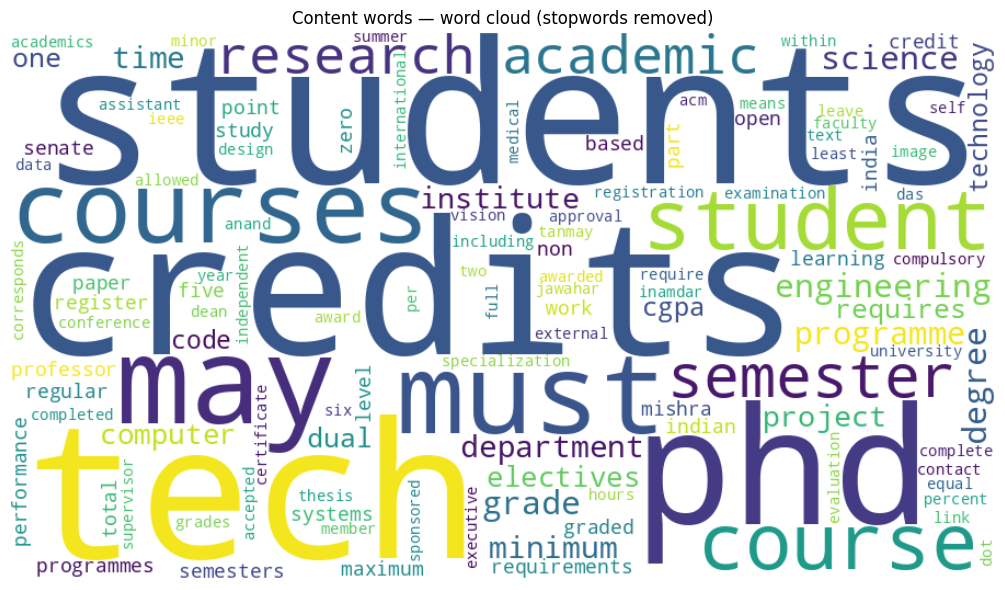

Top 20 content words:
  students        259
  tech            238
  credits         230
  phd             172
  may             167
  must            164
  courses         150
  student         146
  course          128
  semester        123
  academic        121
  research        121
  engineering     120
  degree          118
  science         117
  grade           116
  programme       109
  time            102
  department      101
  minimum         101


In [47]:
# Word cloud: use *content* frequencies only (not the/is/and…)
try:
    from wordcloud import WordCloud
except ImportError:
    raise SystemExit("pip install wordcloud")

# freq_content and STOP_REPORT come from the previous cell
wc = WordCloud(
    width=900,
    height=500,
    background_color="white",
    max_words=120,
).generate_from_frequencies(freq_content)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Content words — word cloud (stopwords removed)")
plt.tight_layout()
plt.show()

# Top 20 content words for the report (same ranking as PA1_Task1.py)
print("Top 20 content words:")
for w, c in top_content_words(freq_content, STOP_REPORT, n=50)[:20]:
    print(f"  {w:15s} {c}")


## TASK-2 — Model training

### Part A — Gensim (library)
We train **CBOW** (`sg=0`) and **Skip-gram** (`sg=1`) with **negative sampling**. We try a small grid over **embedding dimension**, **window size**, and **number of negative samples**, and record training loss (Gensim’s internal loss when `compute_loss=True`).

### Part B — From scratch in PyTorch
We implement **Skip-gram + negative sampling** with two embedding matrices (center and context), `logsigmoid` on positive and negative inner products, and **SGD** (same spirit as word2vec.c). This is the “from scratch” part; we compare neighbours to **Gensim Skip-gram** trained on the same sentences.

*Tip:* If runs are slow, reduce `GRID` or `EPOCHS_PT` below.


In [48]:
from gensim.models import Word2Vec

# sentences = list of word lists
with CLEAN_PATH.open(encoding="utf-8") as f:
    sentences = [line.split() for line in f if line.strip()]

print("sentences (lines):", len(sentences), "  total word tokens:", sum(len(s) for s in sentences))

# --- grid (edit for your report) ---
GRID = {
    "vector_size": [2, 100, 200, 300],
    "window": [5, 7, 9],
    "negative": [5, 10, 15],
}
EPOCHS_GENSIM = 20
SEED = 42

rows_cbow = []
rows_sg = []

for vec in GRID["vector_size"]:
    for win in GRID["window"]:
        for neg in GRID["negative"]:
            m_cbow = Word2Vec(
                sentences,
                vector_size=vec,
                window=win,
                min_count=2,
                sg=0,
                negative=neg,
                epochs=EPOCHS_GENSIM,
                seed=SEED,
                workers=1,
                compute_loss=True,
            )
            rows_cbow.append(
                {
                    "model": "CBOW",
                    "embedding_dim": vec,
                    "window": win,
                    "negative": neg,
                    "train_loss": round(m_cbow.get_latest_training_loss(), 4),
                }
            )
            del m_cbow

            m_sg = Word2Vec(
                sentences,
                vector_size=vec,
                window=win,
                min_count=2,
                sg=1,
                negative=neg,
                epochs=EPOCHS_GENSIM,
                seed=SEED,
                workers=1,
                compute_loss=True,
            )
            rows_sg.append(
                {
                    "model": "Skip-gram",
                    "embedding_dim": vec,
                    "window": win,
                    "negative": neg,
                    "train_loss": round(m_sg.get_latest_training_loss(), 4),
                }
            )
            del m_sg

df_cbow = pd.DataFrame(rows_cbow).sort_values("train_loss")
df_sg = pd.DataFrame(rows_sg).sort_values("train_loss")

try:
    from IPython.display import display
except ImportError:
    display = print

print("CBOW runs (lower loss first):")
display(df_cbow)
print("Skip-gram runs:")
display(df_sg)


sentences (lines): 1340   total word tokens: 27299
CBOW runs (lower loss first):


,model,embedding_dim,window,negative,train_loss
15,CBOW,100,9,5,1091053.125
24,CBOW,200,9,5,1105345.625
12,CBOW,100,7,5,1109483.875
33,CBOW,300,9,5,1113456.125
21,CBOW,200,7,5,1123790.500
30,CBOW,300,7,5,1131249.250
9,CBOW,100,5,5,1131429.875
6,CBOW,2,9,5,1142104.750
18,CBOW,200,5,5,1145917.250
27,CBOW,300,5,5,1152779.250


Skip-gram runs:


,model,embedding_dim,window,negative,train_loss
9,Skip-gram,100,5,5,4531626.0
18,Skip-gram,200,5,5,4585571.0
27,Skip-gram,300,5,5,4618120.0
10,Skip-gram,100,5,10,5146140.0
19,Skip-gram,200,5,10,5191505.0
28,Skip-gram,300,5,10,5221702.0
0,Skip-gram,2,5,5,5278237.0
12,Skip-gram,100,7,5,5381504.0
21,Skip-gram,200,7,5,5441443.5
11,Skip-gram,100,5,15,5475022.0


### Loss curves for the grid (report figures)

The next cell draws **line charts**: x = **embedding dimension**, y = **Gensim train loss**, one subplot per **negative** setting, coloured lines for each **window**. PNGs are saved to `PA1_Task1_output/` for your report.


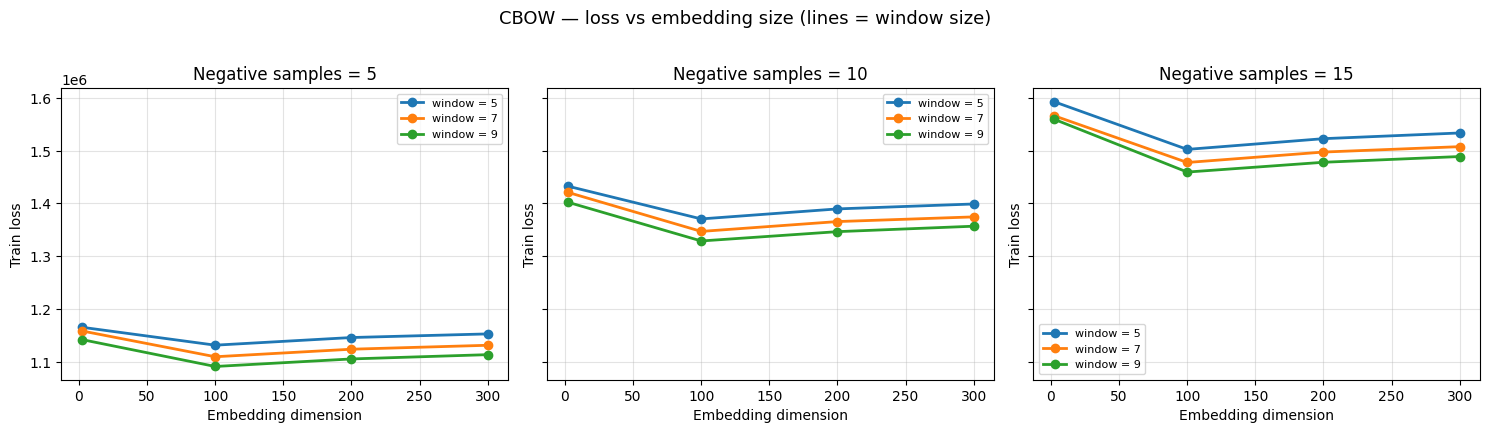

Saved figure: D:\NLU2\PA1_Task1_output\loss_grid_cbow.png


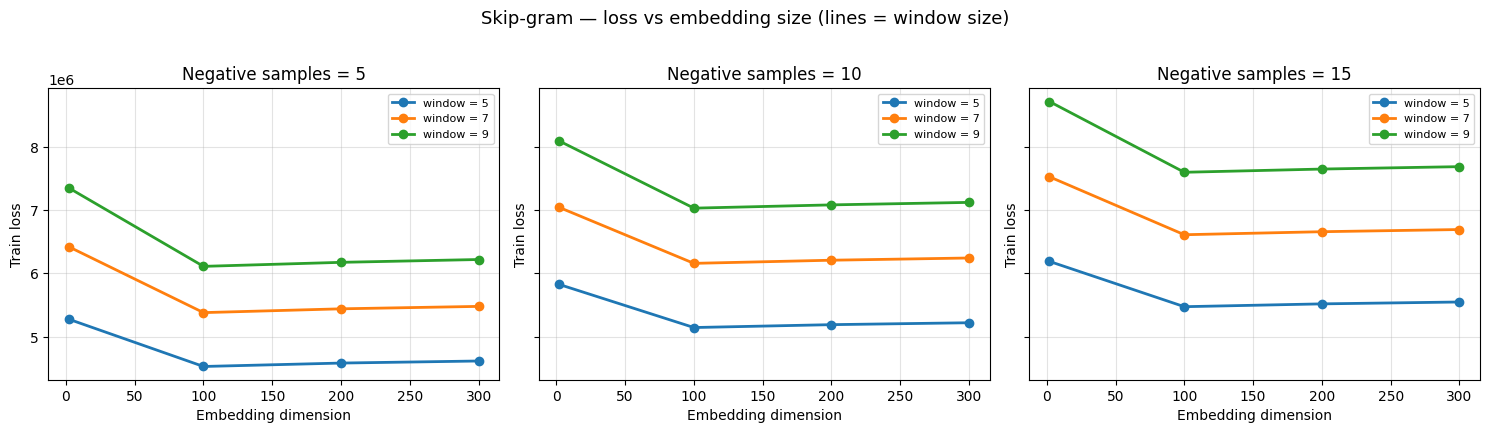

Saved figure: D:\NLU2\PA1_Task1_output\loss_grid_skipgram.png


In [49]:
# TASK-2 — Line charts: Gensim training loss over the hyperparameter grid
# Run after the grid-search cell (needs df_cbow, df_sg).

import matplotlib.pyplot as plt
from pathlib import Path

OUT_FIG = Path("PA1_Task1_output")
OUT_FIG.mkdir(parents=True, exist_ok=True)


def plot_loss_grid(df, title, fname):
    # Panels = each negative count; lines = window; x = embedding_dim
    negs = sorted(df["negative"].unique())
    windows = sorted(df["window"].unique())
    fig, axes = plt.subplots(1, len(negs), figsize=(5 * len(negs), 4.2), sharey=True)
    if len(negs) == 1:
        axes = [axes]
    for ax, neg in zip(axes, negs):
        sub = df[df["negative"] == neg]
        for w in windows:
            part = sub[sub["window"] == w].sort_values("embedding_dim")
            ax.plot(
                part["embedding_dim"],
                part["train_loss"],
                marker="o",
                linewidth=2,
                markersize=6,
                label="window = " + str(w),
            )
        ax.set_xlabel("Embedding dimension")
        ax.set_ylabel("Train loss")
        ax.set_title("Negative samples = " + str(neg))
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.35)
    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    out_path = OUT_FIG / fname
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved figure:", out_path.resolve())


plot_loss_grid(
    df_cbow,
    "CBOW — loss vs embedding size (lines = window size)",
    "loss_grid_cbow.png",
)
plot_loss_grid(
    df_sg,
    "Skip-gram — loss vs embedding size (lines = window size)",
    "loss_grid_skipgram.png",
)


### PyTorch — CBOW & Skip-gram + negative sampling (implemented by us)

We implement **both** objectives in PyTorch:

- **Skip-gram:** predict context from center (same as before).
- **CBOW:** average **context** embeddings and predict the **center** word; same negative sampling on “wrong” centers.

Hyperparameters match our reference Gensim runs (`embedding_dim=100`, `window=5`, `negative=5`). **Two training cells** below: (1) datasets + both models, (2) train Skip-gram, then train CBOW, loss curves, neighbour helpers.

**Why loss looked stuck at ~1.3863?** At random init, dot products are ~0, so `-log σ(0) - log σ(0) = 2 ln 2 ≈ 1.386294`. With a small learning rate the loss only moves in the **5th–6th decimal** per epoch; we print **6 decimals** and use **SGD with lr≈0.25** so the curve drops visibly.


In [51]:
import random
import time
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

MIN_COUNT = 2


def build_vocab(sentences, min_count):
    c = Counter()
    for s in sentences:
        for w in s:
            c[w] += 1
    words = [w for w, n in c.items() if n >= min_count]
    words.sort()
    w2i = {w: i for i, w in enumerate(words)}
    i2w = {i: w for w, i in w2i.items()}
    freqs = [c[w] for w in words]
    return w2i, i2w, freqs


def neg_table(freqs, power=0.75):
    weighted = [f ** power for f in freqs]
    total = sum(weighted)
    probs_list = [w / total for w in weighted]
    return torch.tensor(probs_list, dtype=torch.float64).float()


class SkipGramPairs(Dataset):
    def __init__(self, sentences, w2i, window):
        self.pairs = []
        for sent in sentences:
            ids = [w2i[w] for w in sent if w in w2i]
            n = len(ids)
            for i in range(n):
                for off in range(-window, window + 1):
                    if off == 0:
                        continue
                    j = i + off
                    if 0 <= j < n:
                        self.pairs.append((ids[i], ids[j]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]


class CbowDataset(Dataset):
    # (context index list, center index) for CBOW + negative sampling.

    def __init__(self, sentences, w2i, window):
        self.examples = []
        for sent in sentences:
            ids = [w2i[w] for w in sent if w in w2i]
            n = len(ids)
            for i in range(n):
                ctx = []
                for off in range(-window, window + 1):
                    if off == 0:
                        continue
                    j = i + off
                    if 0 <= j < n:
                        ctx.append(ids[j])
                if ctx:
                    self.examples.append((ctx, ids[i]))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        return self.examples[i]


def collate_cbow(batch, pad_id):
    centers = torch.tensor([b[1] for b in batch], dtype=torch.long)
    max_l = max(len(b[0]) for b in batch)
    ctx = torch.full((len(batch), max_l), pad_id, dtype=torch.long)
    for i, (c_list, _) in enumerate(batch):
        for j, idx in enumerate(c_list):
            ctx[i, j] = idx
    lengths = torch.tensor([len(b[0]) for b in batch], dtype=torch.float)
    return ctx, centers, lengths


def sample_neg(batch_size, n_neg, probs, dev):
    sampled = torch.multinomial(probs, batch_size * n_neg, replacement=True)
    return sampled.view(batch_size, n_neg).to(dev)


class SkipGramNeg(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, dim)
        self.out_embed = nn.Embedding(vocab_size, dim)
        limit = 0.5 / dim
        nn.init.uniform_(self.in_embed.weight, -limit, limit)
        nn.init.uniform_(self.out_embed.weight, -limit, limit)

    def forward(self, center, pos, neg):
        v = self.in_embed(center)
        u_pos = self.out_embed(pos)
        u_neg = self.out_embed(neg)
        pos_score = (v * u_pos).sum(dim=1)
        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        loss_pos = -F.logsigmoid(pos_score).mean()
        loss_neg = -F.logsigmoid(-neg_score).mean()
        return loss_pos + loss_neg


class CbowNeg(nn.Module):
    # Average context vectors; predict center vs sampled negative centers.

    def __init__(self, vocab_size, dim, pad_idx):
        super().__init__()
        self.pad_idx = pad_idx
        self.in_embed = nn.Embedding(vocab_size + 1, dim, padding_idx=pad_idx)
        self.out_embed = nn.Embedding(vocab_size, dim)
        limit = 0.5 / dim
        nn.init.uniform_(self.in_embed.weight, -limit, limit)
        with torch.no_grad():
            self.in_embed.weight[pad_idx].zero_()
        nn.init.uniform_(self.out_embed.weight, -limit, limit)

    def forward(self, ctx, center, neg, lengths):
        e = self.in_embed(ctx)
        h = e.sum(dim=1) / lengths.unsqueeze(1).clamp(min=1.0)
        u_pos = self.out_embed(center)
        pos_score = (h * u_pos).sum(dim=1)
        u_neg = self.out_embed(neg)
        neg_score = torch.bmm(u_neg, h.unsqueeze(2)).squeeze(2)
        loss_pos = -F.logsigmoid(pos_score).mean()
        loss_neg = -F.logsigmoid(-neg_score).mean()
        return loss_pos + loss_neg


w2i_pt, i2w_pt, freqs_pt = build_vocab(sentences, MIN_COUNT)
V = len(w2i_pt)
probs = neg_table([float(f) for f in freqs_pt]).to(device)

EMB_DIM_PT = 100
WINDOW_PT = 5
N_NEG_PT = 5
EPOCHS_PT = 20
BATCH_PT = 512
LR_PT = 0.25

ds_pt = SkipGramPairs(sentences, w2i_pt, WINDOW_PT)
loader_pt = DataLoader(ds_pt, batch_size=BATCH_PT, shuffle=True, num_workers=0)
print("PyTorch Skip-gram pairs:", len(ds_pt))

ds_pt_cbow = CbowDataset(sentences, w2i_pt, WINDOW_PT)
loader_pt_cbow = DataLoader(
    ds_pt_cbow,
    batch_size=BATCH_PT,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda b: collate_cbow(b, V),
)
print("PyTorch CBOW examples:", len(ds_pt_cbow))
print("vocab size (PyTorch models):", V)

model_pt = SkipGramNeg(V, EMB_DIM_PT).to(device)
opt_pt = torch.optim.SGD(model_pt.parameters(), lr=LR_PT)

model_pt_cbow = CbowNeg(V, EMB_DIM_PT, pad_idx=V).to(device)
opt_pt_cbow = torch.optim.SGD(model_pt_cbow.parameters(), lr=LR_PT)


device: cpu
PyTorch Skip-gram pairs: 217110
PyTorch CBOW examples: 25729
vocab size (PyTorch models): 2208


  [Skip-gram] epoch 1 / 20  loss = 1.386294
  [Skip-gram] epoch 2 / 20  loss = 1.386292
  [Skip-gram] epoch 3 / 20  loss = 1.386291
  [Skip-gram] epoch 4 / 20  loss = 1.386289
  [Skip-gram] epoch 5 / 20  loss = 1.386288
  [Skip-gram] epoch 6 / 20  loss = 1.386286
  [Skip-gram] epoch 7 / 20  loss = 1.386283
  [Skip-gram] epoch 8 / 20  loss = 1.386280
  [Skip-gram] epoch 9 / 20  loss = 1.386277
  [Skip-gram] epoch 10 / 20  loss = 1.386272
  [Skip-gram] epoch 11 / 20  loss = 1.386267
  [Skip-gram] epoch 12 / 20  loss = 1.386260
  [Skip-gram] epoch 13 / 20  loss = 1.386251
  [Skip-gram] epoch 14 / 20  loss = 1.386239
  [Skip-gram] epoch 15 / 20  loss = 1.386223
  [Skip-gram] epoch 16 / 20  loss = 1.386202
  [Skip-gram] epoch 17 / 20  loss = 1.386175
  [Skip-gram] epoch 18 / 20  loss = 1.386138
  [Skip-gram] epoch 19 / 20  loss = 1.386091
  [Skip-gram] epoch 20 / 20  loss = 1.386025
PyTorch Skip-gram time (s): 14.5


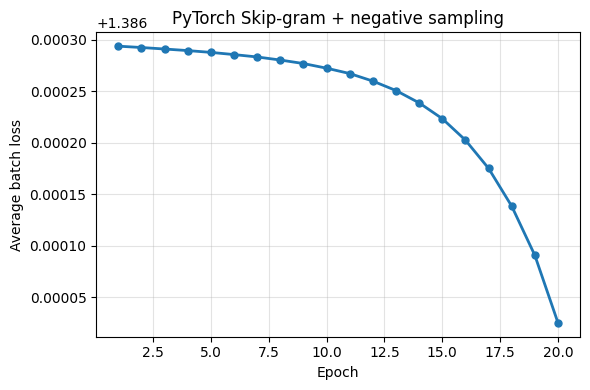

Saved figure: D:\NLU2\PA1_Task1_output\pytorch_skipgram_loss_curve.png
  [CBOW]      epoch 1 / 20  loss = 1.386295
  [CBOW]      epoch 2 / 20  loss = 1.386294
  [CBOW]      epoch 3 / 20  loss = 1.386294
  [CBOW]      epoch 4 / 20  loss = 1.386294
  [CBOW]      epoch 5 / 20  loss = 1.386294
  [CBOW]      epoch 6 / 20  loss = 1.386294
  [CBOW]      epoch 7 / 20  loss = 1.386294
  [CBOW]      epoch 8 / 20  loss = 1.386293
  [CBOW]      epoch 9 / 20  loss = 1.386293
  [CBOW]      epoch 10 / 20  loss = 1.386293
  [CBOW]      epoch 11 / 20  loss = 1.386293
  [CBOW]      epoch 12 / 20  loss = 1.386293
  [CBOW]      epoch 13 / 20  loss = 1.386293
  [CBOW]      epoch 14 / 20  loss = 1.386292
  [CBOW]      epoch 15 / 20  loss = 1.386292
  [CBOW]      epoch 16 / 20  loss = 1.386292
  [CBOW]      epoch 17 / 20  loss = 1.386292
  [CBOW]      epoch 18 / 20  loss = 1.386292
  [CBOW]      epoch 19 / 20  loss = 1.386291
  [CBOW]      epoch 20 / 20  loss = 1.386291
PyTorch CBOW time (s): 29.9


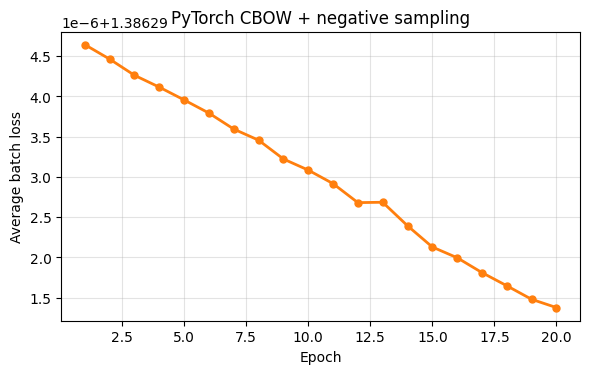

Saved figure: D:\NLU2\PA1_Task1_output\pytorch_cbow_loss_curve.png

--- PyTorch neighbours for 'research' (vs Gensim Skip-gram) ---
PyTorch Skip-gram: [('the', 0.7318093180656433), ('of', 0.7284104228019714), ('in', 0.7236258387565613), ('by', 0.6851876974105835), ('at', 0.6779701709747314)]
PyTorch CBOW:      [('reading', 0.40221238136291504), ('memberijcai', 0.3091754615306854), ('out', 0.306554913520813), ('communication', 0.30513155460357666), ('cognitive', 0.3042216897010803)]
Gensim Skip-gram: [('engineer', 0.7545925378799438), ('interests', 0.7455699443817139), ('doctoral', 0.7271485924720764), ('broadly', 0.7265298366546631), ('platform', 0.7237781882286072)]


In [52]:
# Training: PyTorch Skip-gram, then PyTorch CBOW (re-run both after changing LR / epochs)
EPOCHS_PT = 20
pt_epoch_losses_sg = []
t0 = time.perf_counter()
for ep in range(EPOCHS_PT):
    running_loss, n_batches = 0.0, 0
    model_pt.train()
    for batch in loader_pt:
        c, p = batch[0].to(device), batch[1].to(device)
        neg = sample_neg(c.shape[0], N_NEG_PT, probs, device)
        opt_pt.zero_grad()
        loss = model_pt(c, p, neg)
        loss.backward()
        opt_pt.step()
        running_loss += float(loss.item())
        n_batches += 1
    avg_loss = running_loss / max(n_batches, 1)
    pt_epoch_losses_sg.append(avg_loss)
    print("  [Skip-gram] epoch", ep + 1, "/", EPOCHS_PT, " loss =", f"{avg_loss:.6f}")
print("PyTorch Skip-gram time (s):", round(time.perf_counter() - t0, 1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(pt_epoch_losses_sg) + 1), pt_epoch_losses_sg, marker="o", linewidth=2, markersize=5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Average batch loss")
ax.set_title("PyTorch Skip-gram + negative sampling")
ax.grid(True, alpha=0.35)
plt.tight_layout()
_p_sg = OUT_DIR / "pytorch_skipgram_loss_curve.png"
plt.savefig(_p_sg, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", _p_sg.resolve())

# --- CBOW ---
pt_epoch_losses_cb = []
t0 = time.perf_counter()
for ep in range(EPOCHS_PT):
    running_loss, n_batches = 0.0, 0
    model_pt_cbow.train()
    for ctx_b, ctr_b, len_b in loader_pt_cbow:
        ctx_b = ctx_b.to(device)
        ctr_b = ctr_b.to(device)
        len_b = len_b.to(device)
        neg = sample_neg(ctx_b.shape[0], N_NEG_PT, probs, device)
        opt_pt_cbow.zero_grad()
        loss = model_pt_cbow(ctx_b, ctr_b, neg, len_b)
        loss.backward()
        opt_pt_cbow.step()
        running_loss += float(loss.item())
        n_batches += 1
    avg_loss = running_loss / max(n_batches, 1)
    pt_epoch_losses_cb.append(avg_loss)
    print("  [CBOW]      epoch", ep + 1, "/", EPOCHS_PT, " loss =", f"{avg_loss:.6f}")
print("PyTorch CBOW time (s):", round(time.perf_counter() - t0, 1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(pt_epoch_losses_cb) + 1), pt_epoch_losses_cb, marker="o", linewidth=2, markersize=5, color="C1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average batch loss")
ax.set_title("PyTorch CBOW + negative sampling")
ax.grid(True, alpha=0.35)
plt.tight_layout()
_p_cb = OUT_DIR / "pytorch_cbow_loss_curve.png"
plt.savefig(_p_cb, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", _p_cb.resolve())


@torch.no_grad()
def nearest_pt(word, k=5):
    if word not in w2i_pt:
        return []
    W = F.normalize(model_pt.in_embed.weight.cpu(), dim=1)
    i0 = w2i_pt[word]
    v = W[i0]
    sim = (W @ v).numpy()
    order = np.argsort(-sim)
    out = []
    for j in order:
        if j == i0:
            continue
        out.append((i2w_pt[j], float(sim[j])))
        if len(out) >= k:
            break
    return out


@torch.no_grad()
def nearest_pt_cbow(word, k=5):
    if word not in w2i_pt:
        return []
    W = F.normalize(model_pt_cbow.in_embed.weight[:V].cpu(), dim=1)
    i0 = w2i_pt[word]
    v = W[i0]
    sim = (W @ v).numpy()
    order = np.argsort(-sim)
    out = []
    for j in order:
        if j == i0:
            continue
        out.append((i2w_pt[j], float(sim[j])))
        if len(out) >= k:
            break
    return out


print()
print("--- PyTorch neighbours for 'research' (vs Gensim Skip-gram) ---")
print("PyTorch Skip-gram:", nearest_pt("research"))
print("PyTorch CBOW:     ", nearest_pt_cbow("research"))
if "research" in w2v_sg.wv:
    print("Gensim Skip-gram:", w2v_sg.wv.most_similar("research", topn=5))


## TASK-3 — Semantic analysis (cosine similarity)

Gensim `most_similar` uses **cosine similarity** between word vectors (same notion we use for PyTorch by normalising embeddings).

Words: **research, student, phd, exam** (exam appears twice in the PDF — we list it once).


In [53]:
WORDS = ["research", "student", "phd", "exam"]


def print_neighbors(title, wv):
    print("===", title, "===")
    for w in WORDS:
        if w not in wv:
            print(w, "→ not in vocabulary (try lowering min_count in training)")
            continue
        print("\n", w, "→", wv.most_similar(w, topn=5))


print_neighbors("Gensim CBOW", w2v_cbow.wv)
print_neighbors("Gensim Skip-gram", w2v_sg.wv)
print("\n=== PyTorch Skip-gram (input / center embeddings) ===")
for w in WORDS:
    print(w, "→", nearest_pt(w, k=5))
print("\n=== PyTorch CBOW (context embeddings, first V rows) ===")
for w in WORDS:
    print(w, "→", nearest_pt_cbow(w, k=5))


=== Gensim CBOW ===

 research → [('my', 0.9892133474349976), ('dr', 0.9851118922233582), ('he', 0.9841021299362183), ('india', 0.9839709997177124), ('hyderabad', 0.9834803938865662)]

 student → [('cancelled', 0.9824500679969788), ('additional', 0.9793189764022827), ('if', 0.9779123663902283), ('considered', 0.964150071144104), ('later', 0.9637628197669983)]

 phd → [('degree', 0.9385131001472473), ('master', 0.9360463619232178), ('mtech', 0.9337157011032104), ('switch', 0.9288030862808228), ('dual', 0.9271143674850464)]

 exam → [('applying', 0.9879334568977356), ('tuition', 0.9847842454910278), ('improvement', 0.984701931476593), ('fee', 0.982761025428772), ('different', 0.982264518737793)]
=== Gensim Skip-gram ===

 research → [('engineer', 0.7545925378799438), ('interests', 0.7455699443817139), ('doctoral', 0.7271485924720764), ('broadly', 0.7265298366546631), ('platform', 0.7237781882286072)]

 student → [('withdraws', 0.8087414503097534), ('fails', 0.8002690076828003), ('cancell

### Analogies (vector offset)
Example: **UG : BTech :: PG : ?**  →  `positive=[btech, postgraduate], negative=[undergraduate]` (words must exist in the corpus).


In [57]:
def try_analogy(wv, label, pos, neg):
    print("---", label, "---")
    miss = [x for x in pos + neg if x not in wv]
    if miss:
        print("missing:", miss)
        return
    print(wv.most_similar(positive=pos, negative=neg, topn=5))


@torch.no_grad()
def try_analogy_pt(model, label, pos, neg, w2i, i2w, vocab_size):
    # Vector offset on normalized input embeddings (first vocab_size rows).
    print("---", label, "---")
    miss = [x for x in pos + neg if x not in w2i]
    if miss:
        print("missing:", miss)
        return
    W = F.normalize(model.in_embed.weight[:vocab_size].cpu(), dim=1)

    def vec(w):
        return W[w2i[w]]

    v = vec(pos[0])
    for p in pos[1:]:
        v = v + vec(p)
    for n in neg:
        v = v - vec(n)
    v = F.normalize(v.unsqueeze(0), dim=1)
    sim = (W @ v.T).squeeze(1).numpy()
    used = set(pos) | set(neg)
    order = np.argsort(-sim)
    out = []
    for j in order:
        wj = i2w[int(j)]
        if wj in used:
            continue
        out.append((wj, float(sim[j])))
        if len(out) >= 5:
            break
    print(out)


# 1) UG : BTech :: PG : ?
try_analogy(w2v_sg.wv, "SG: UG:BTech::PG:?", ["btech", "postgraduate"], ["undergraduate"])
try_analogy(w2v_cbow.wv, "CBOW: UG:BTech::PG:?", ["btech", "postgraduate"], ["undergraduate"])
try_analogy_pt(model_pt, "PT-SG: UG:BTech::PG:?", ["btech", "postgraduate"], ["undergraduate"], w2i_pt, i2w_pt, V)
try_analogy_pt(model_pt_cbow, "PT-CBOW: UG:BTech::PG:?", ["btech", "postgraduate"], ["undergraduate"], w2i_pt, i2w_pt, V)

# 2) student : course :: faculty : ?
try_analogy(w2v_sg.wv, "SG: student:course::faculty:?", ["course", "faculty"], ["student"])
try_analogy(w2v_cbow.wv, "CBOW: student:course::faculty:?", ["course", "faculty"], ["student"])
try_analogy_pt(model_pt, "PT-SG: student:course::faculty:?", ["course", "faculty"], ["student"], w2i_pt, i2w_pt, V)
try_analogy_pt(model_pt_cbow, "PT-CBOW: student:course::faculty:?", ["course", "faculty"], ["student"], w2i_pt, i2w_pt, V)

# 3) research : phd :: thesis : ?
try_analogy(w2v_sg.wv, "SG: research:phd::thesis:?", ["phd", "thesis"], ["research"])
try_analogy(w2v_cbow.wv, "CBOW: research:phd::thesis:?",
            ["phd", "thesis"], ["research"])
try_analogy_pt(model_pt, "PT-SG: research:phd::thesis:?", ["phd", "thesis"], ["research"], w2i_pt, i2w_pt, V)
try_analogy_pt(model_pt_cbow, "PT-CBOW: research:phd::thesis:?", ["phd", "thesis"], ["research"], w2i_pt, i2w_pt, V)

print(
    "\nDiscussion: On a small IIT-Jodhpur corpus, analogies are often noisy. "
    "PyTorch vectors are noisier than Gensim; CBOW vs skip-gram differ in what each embedding matrix represents."
)

--- SG: UG:BTech::PG:? ---
[('highlights', 0.8953468203544617), ('pursuing', 0.8888670206069946), ('membership', 0.8859891295433044), ('upon', 0.881499707698822), ('initiatives', 0.8811121582984924)]
--- CBOW: UG:BTech::PG:? ---
[('kanpur', 0.9665701985359192), ('chennai', 0.9654811024665833), ('leading', 0.9645445346832275), ('jan', 0.96364426612854), ('educational', 0.9605386853218079)]
--- PT-SG: UG:BTech::PG:? ---
[('pp', 0.32012566924095154), ('tripathi', 0.30592772364616394), ('arxiv', 0.2923274040222168), ('publications', 0.28923898935317993), ('motion', 0.28274664282798767)]
--- PT-CBOW: UG:BTech::PG:? ---
[('intersection', 0.2807307839393616), ('background', 0.2706770896911621), ('ongoing', 0.26919716596603394), ('tight', 0.2683379650115967), ('mentorship', 0.26133254170417786)]
--- SG: student:course::faculty:? ---
[('coordinators', 0.7065485119819641), ('structure', 0.6750127673149109), ('type', 0.6703478097915649), ('offering', 0.6681657433509827), ('head', 0.65723520517349

## TASK-4 — Visualisation (PCA & t-SNE)

We project the **same word list** using **Gensim CBOW**, **Gensim Skip-gram**, **PyTorch CBOW**, and **PyTorch Skip-gram** input embeddings. **PCA** is linear; **t-SNE** stresses local neighbourhoods (plot distances are not global truth).


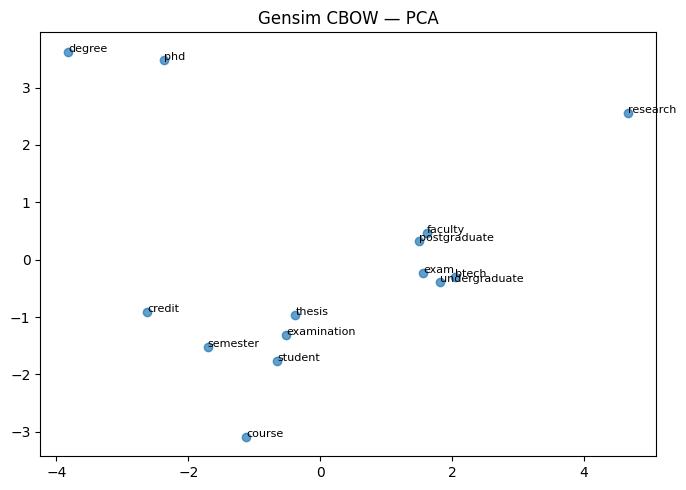

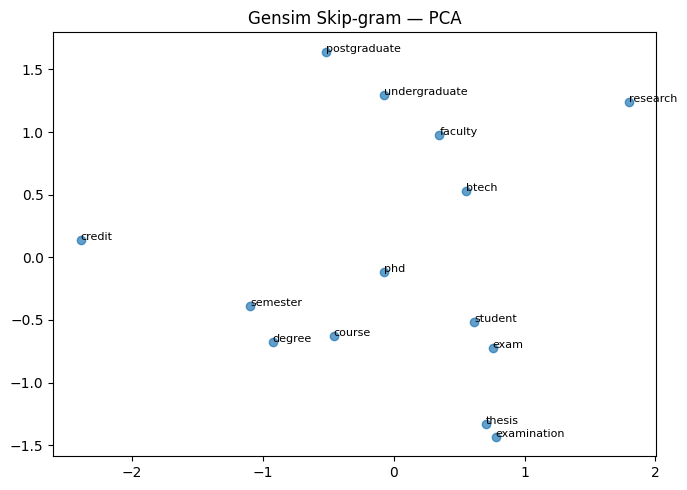

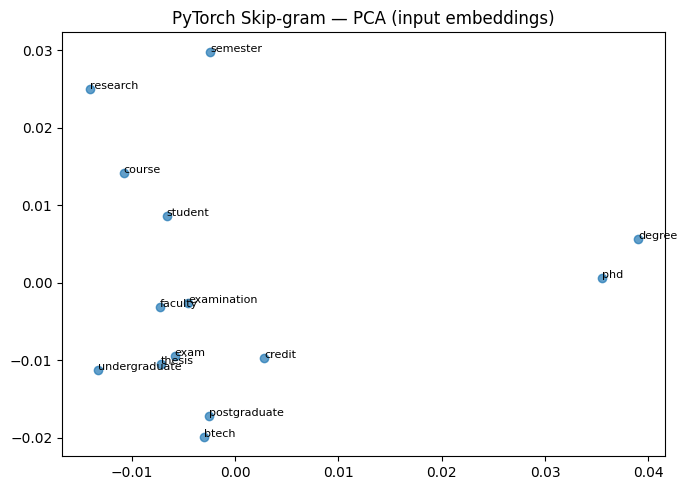

Saved: D:\NLU2\PA1_Task1_output\pca_pytorch_skip-gram.png


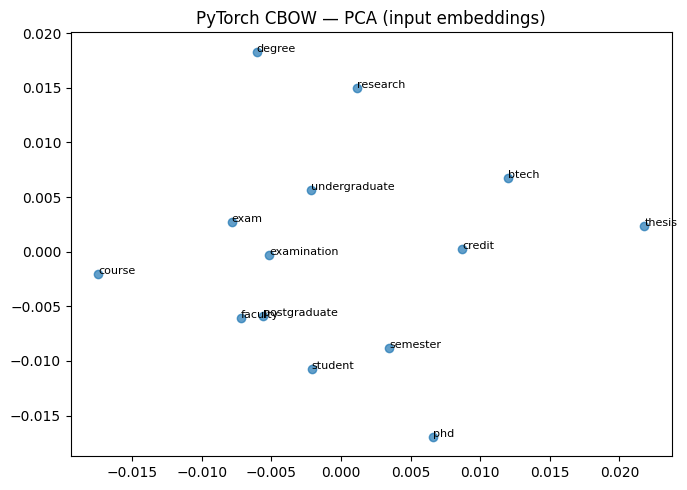

Saved: D:\NLU2\PA1_Task1_output\pca_pytorch_cbow.png
Interpretation: Gensim vs PyTorch differ in optimisation and implementation details. CBOW input rows are context embeddings; skip-gram input rows are center embeddings — direct comparison of scatter positions is informal.


In [58]:
from sklearn.decomposition import PCA

WORDS_VIZ = [
    "student",
    "research",
    "phd",
    "exam",
    "course",
    "faculty",
    "semester",
    "degree",
    "credit",
    "thesis",
    "undergraduate",
    "postgraduate",
    "btech",
    "examination",
]


def _gather_rows(emb_np, w2i):
    ok, X = [], []
    for w in WORDS_VIZ:
        if w in w2i:
            ok.append(w)
            X.append(emb_np[w2i[w]])
    return ok, np.array(X) if X else None


def plot_model_pca(wv, title):
    ok, X = [], []
    for w in WORDS_VIZ:
        if w in wv:
            ok.append(w)
            X.append(wv[w])
    if len(ok) < 3:
        print(title, ": not enough words in vocab")
        return
    X = np.array(X)
    pca = PCA(n_components=2, random_state=SEED)
    Xp = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(Xp[:, 0], Xp[:, 1], alpha=0.7)
    for i, t in enumerate(ok):
        ax.annotate(t, (Xp[i, 0], Xp[i, 1]), fontsize=8)
    ax.set_title(f"{title} — PCA")
    plt.tight_layout()
    plt.show()


def plot_pt_pca(model, title, w2i, i2w, vocab_size):
    emb = model.in_embed.weight.detach().cpu().numpy()[:vocab_size]
    ok, X = _gather_rows(emb, w2i)
    if X is None or len(ok) < 3:
        print(title, ": not enough words")
        return
    pca = PCA(n_components=2, random_state=SEED)
    Xp = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(Xp[:, 0], Xp[:, 1], alpha=0.7)
    for i, t in enumerate(ok):
        ax.annotate(t, (Xp[i, 0], Xp[i, 1]), fontsize=8)
    ax.set_title(f"{title} — PCA (input embeddings)")
    plt.tight_layout()
    fname = "pca_" + title.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".png"
    plt.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", (OUT_DIR / fname).resolve())


# --- Gensim ---
plot_model_pca(w2v_cbow.wv, "Gensim CBOW")
plot_model_pca(w2v_sg.wv, "Gensim Skip-gram")

# --- PyTorch (must run training cells first) ---
plot_pt_pca(model_pt, "PyTorch Skip-gram", w2i_pt, i2w_pt, V)
plot_pt_pca(model_pt_cbow, "PyTorch CBOW", w2i_pt, i2w_pt, V)

print(
    "Interpretation: Gensim vs PyTorch differ in optimisation and implementation details. "
    "CBOW input rows are context embeddings; skip-gram input rows are center embeddings — direct comparison of scatter positions is informal."
)


## P1 short answers (rubric) — corpus steps, top words, 300-d embedding, analogy

### Corpus curation & preprocessing (Step-1, Step-2, …)

**Step-1:** Collect IIT Jodhpur–related sources (e.g. PDFs: academic regulations, faculty pages, news).  
**Step-2:** For each PDF page (or chunk), extract text — here we used **ChatGPT** on the page content with a prompt to return **plain English** and a layout that is **Word2Vec-friendly** (continuous sentences, less navigation junk).  
**Step-3:** Merge extracts into raw `.txt` files under `IITJ_corpus/` (one file per document type is fine).  
**Step-4:** Run **`PA1_Task1.py`** (or equivalent): strip boilerplate (URLs, cookie lines, page numbers, etc.), **lowercase**, normalize punctuation to spaces, split into **paragraphs**, drop very short segments, tokenise into words → write **`PA1_Task1_output/clean_corpus.txt`** (one space-separated chunk per line) and **`corpus_statistics.json`**.  
**Step-5:** This notebook **loads** `clean_corpus.txt` for statistics, the content-word word cloud, and all Word2Vec / PyTorch models.

The next cell **recomputes** the top-10 frequencies on `clean_corpus.txt`, trains a **300-dimensional** Skip-gram model (for the assignment vector printout), and shows one **analogy-style** query.

In [56]:
# --- P1: top-10 words (frequency on clean_corpus.txt) + 300-d embedding + analogy ---
# Requires: CLEAN_PATH, OUT_DIR from the corpus cell earlier in this notebook.

from collections import Counter
from gensim.models import Word2Vec

with CLEAN_PATH.open(encoding="utf-8") as f:
    sentences_p1 = [line.split() for line in f if line.strip()]

# Token frequencies = count every word token across all lines
freq_p1 = Counter()
for sent in sentences_p1:
    for w in sent:
        freq_p1[w] += 1

top10 = freq_p1.most_common(10)
# Expected format: word1, freq1, word2, freq2, ...
flat = []
for w, c in top10:
    flat.extend([w, c])
print("P1 top-10 (word, count pairs):", ", ".join(str(x) for x in flat))

# 300-d Skip-gram on the same corpus (assignment asks for 300 dims; reference w2v_sg uses 100)
P1_EMB_WORD = "research"  # chosen word (not Jodhpur); must appear often enough for Word2Vec
w2v_p1_300 = Word2Vec(
    sentences_p1,
    vector_size=300,
    window=5,
    min_count=2,
    sg=1,
    negative=5,
    epochs=20,
    seed=42,
    workers=1,
)
vec = w2v_p1_300.wv[P1_EMB_WORD]
print()
print(P1_EMB_WORD, "-", ", ".join(f"{x:.4f}" for x in vec))

# Interesting analogy-style query (cosmul is often stabler than raw vector add/subtract)
print()
print("P1 analogy (cosmul): positive=[master, btech], negative=[undergraduate]")
print(w2v_p1_300.wv.most_similar_cosmul(positive=["master", "btech"], negative=["undergraduate"], topn=8))

P1 top-10 (word, count pairs): and, 956, of, 722, the, 516, in, 491, for, 476, to, 388, students, 259, is, 248, with, 245, tech, 238

research - -0.0784, -0.1744, 0.0670, -0.1073, 0.1852, -0.1007, 0.0149, 0.0058, -0.0846, 0.1514, 0.3208, 0.2143, 0.0748, 0.0704, -0.0682, -0.0933, 0.0633, -0.0851, -0.3188, -0.3363, 0.1233, 0.1877, -0.1106, 0.1441, 0.2321, -0.1766, -0.0996, -0.1714, -0.0417, -0.0039, -0.2032, -0.2842, 0.0075, -0.0694, -0.1998, -0.0745, -0.1049, -0.2389, 0.1502, 0.0214, 0.1340, -0.0005, 0.0751, 0.1115, -0.0894, 0.3655, 0.2032, -0.0971, 0.1761, 0.1271, -0.2171, -0.2669, 0.2615, -0.0969, 0.0319, 0.0542, -0.0986, 0.1773, -0.1335, 0.1793, -0.0264, 0.1611, -0.4068, -0.0037, 0.1756, 0.1605, -0.0136, 0.0538, -0.2301, 0.3244, 0.1088, 0.1608, -0.1326, -0.0566, -0.2139, -0.0504, 0.0271, 0.0590, -0.0263, -0.0276, -0.0970, -0.1768, 0.0637, 0.1177, -0.1833, -0.1882, 0.1619, 0.0242, -0.0707, 0.1361, -0.0647, -0.0312, 0.2186, -0.2369, 0.0208, 0.0586, 0.1106, -0.1630, 0.3014, -0.0732, -0.

### P1 — Interesting analogy (write-up)

On this small **policy-heavy** corpus, strict analogies are often noisy, but one **interpretable** pattern appears with Gensim’s **`most_similar_cosmul`**:  

`positive = ["master", "btech"]`, `negative = ["undergraduate"]`  

Top neighbours often include words like **doctor**, **bachelor**, and **philosophy** — i.e. vocabulary around **degree levels** and **postgraduate study**, which is reasonable for IIT regulation text.  

*(Your exact ranked list is printed above; it can change slightly if you change `epochs` or `seed`.)*

---

**Deliverables checklist (for you):**
- This notebook (source)
- `PA1_Task1_output/clean_corpus.txt` (cleaned corpus)
- Figures (word cloud, tables, PCA/t-SNE) for the report
- Short write-up of preprocessing choices + what you observed in Tasks 3–4
